In [2]:
!pip install -q kagglehub xgboost imbalanced-learn

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

### Kaggle Authentication with Colab Secrets

To download the dataset from Kaggle, you need to provide your Kaggle API credentials. The most secure way to do this in Colab is using **Colab Secrets**.

Follow these steps:

1.  **Get your Kaggle Username and API Key**: Go to your Kaggle account settings (kaggle.com/me/account).
    *   Your **Kaggle Username** is displayed at the top of your profile.
    *   Under the 'API' section, click 'Create New API Token'. This will download a `kaggle.json` file to your computer. Open this file with a text editor to find your username and the `key` (e.g., `KGAT_...` string).
2.  **Add to Colab Secrets**:
    *   In Colab, click the "🔑" (Secrets) icon on the left sidebar.
    *   Add a new secret for your **username**: Set 'Name' to `KAGGLE_USERNAME` and 'Value' to your actual Kaggle username. Make sure 'Notebook access' is toggled ON.
    *   Add another new secret for your **API Key**: Set 'Name' to `KAGGLE_KEY` and 'Value' to the `KGAT_...` string you obtained. Make sure 'Notebook access' is toggled ON.
3.  **Run the cell below** to configure Kaggle to use these secrets for authentication.

In [4]:
import json
import os # Import the os module
from google.colab import userdata

# Create the .kaggle directory if it doesn't exist
!mkdir -p ~/.kaggle

# Get Kaggle credentials from Colab Secrets
kaggle_username = userdata.get('KAGGLE_USERNAME')
kaggle_key = userdata.get('KAGGLE_KEY')

if not kaggle_username or not kaggle_key:
    raise ValueError("Kaggle username or key not found in Colab Secrets. Please follow the instructions above.")

# Define the path to kaggle.json, expanding the user home directory
kaggle_json_path = os.path.expanduser("~/.kaggle/kaggle.json")

# Create the kaggle.json file
kaggle_credentials = {"username": kaggle_username, "key": kaggle_key}
with open(kaggle_json_path, "w") as f:
    json.dump(kaggle_credentials, f)

# Set permissions for the kaggle.json file
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle authentication setup complete. You can now download datasets from Kaggle.")

Kaggle authentication setup complete. You can now download datasets from Kaggle.


In [5]:
import os

# List files in the current directory to find the uploaded zip file
print("Files in current directory:")
print(os.listdir('.'))


Files in current directory:
['.config', 'ieee-fraud-detection', 'drive', 'sample_data']


In [6]:
import zipfile
import os

zip_file_name = '/content/ieee-fraud-detection/ieee-fraud-detection.zip'
extraction_path = '/content/ieee-fraud-detection'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"'{zip_file_name}' unzipped to '{extraction_path}/'")

# List the contents of the extracted directory
print(f"Files in '{extraction_path}/':")
print(os.listdir(extraction_path))

'/content/ieee-fraud-detection/ieee-fraud-detection.zip' unzipped to '/content/ieee-fraud-detection/'
Files in '/content/ieee-fraud-detection/':
['train_transaction.csv', 'test_identity.csv', 'test_transaction.csv', 'sample_submission.csv', 'train_identity.csv', 'ieee-fraud-detection.zip']


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


The dataset has been successfully unzipped. Now I will modify the data loading cells to read from this new directory.

In [8]:
# This cell is no longer needed as the download and extraction logic is now in cell FrxvsxNSr3Hj.
# This cell was responsible for unzipping the manually uploaded file, which was found to be corrupted.

The dataset has been unzipped. Now I will modify the data loading cells to read from this new directory.

Please identify the name of your uploaded zip file (e.g., `ieee-fraud-detection.zip`) from the output above. Once you have it, I will generate the code to unzip it and load the data.

In [9]:
train_transaction = pd.read_csv(
    os.path.join(extraction_path, "train_transaction.csv")
)

train_identity = pd.read_csv(
    os.path.join(extraction_path, "train_identity.csv")
)

print("Transaction shape:", train_transaction.shape)
print("Identity shape:", train_identity.shape)

Transaction shape: (590540, 394)
Identity shape: (144233, 41)


In [10]:
df = train_transaction.merge(
    train_identity,
    on="TransactionID",
    how="left"
)

print("Merged dataset shape:", df.shape)

Merged dataset shape: (590540, 434)


In [11]:
print(df["isFraud"].value_counts())

print("\nPercentage:")
print(
    df["isFraud"].value_counts(normalize=True) * 100
)

isFraud
0    569877
1     20663
Name: count, dtype: int64

Percentage:
isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


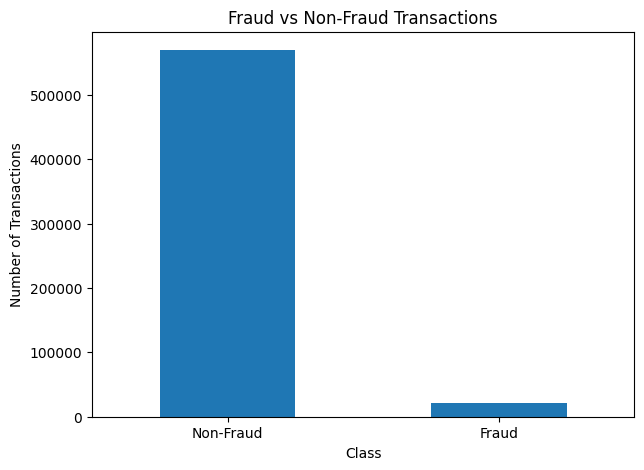

In [12]:
df["isFraud"].value_counts().plot(
    kind="bar",
    figsize=(7, 5)
)

plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.title("Fraud vs Non-Fraud Transactions")
plt.xticks(
    [0, 1],
    ["Non-Fraud", "Fraud"],
    rotation=0
)

plt.show()

In [13]:
X = df.drop(columns=["isFraud"])
y = df["isFraud"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (590540, 433)
y shape: (590540,)


### Memory Optimization for Numeric Features

The previous step likely caused a session crash due to high memory usage when creating a copy of the numeric features from the large `X` DataFrame. To address this, we will implement a function to downcast numeric columns to their most memory-efficient data types (e.g., `int8`, `float16`) without losing data integrity.

This will significantly reduce the memory footprint of `X_numeric`, helping to prevent future memory-related issues.

In [14]:
def reduce_mem_usage(df, verbose=True):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                else:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose: print('Memory usage after optimization is: {:.2f} MB'.format(end_mem))
    if verbose: print('Decreased by {:.1f}%'.format(100 * (start_mem - end_mem) / start_mem))
    return df

In [ ]:
numeric_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns

# Create an empty DataFrame with the correct index to populate with reduced columns
X_numeric_reduced = pd.DataFrame(index=X.index)

for col in numeric_columns:
    # Apply memory reduction to each column individually and add to the new DataFrame
    # verbose=False to avoid printing memory usage for each column
    temp_series = reduce_mem_usage(X[[col]], verbose=False)[col]
    X_numeric_reduced[col] = temp_series

X_numeric = X_numeric_reduced # Assign the reduced DataFrame

print("Number of numerical features:", X_numeric.shape[1])
print("Shape:", X_numeric.shape)

In [1]:
print('Memory usage of X_numeric after optimization: {:.2f} MB'.format(X_numeric.memory_usage().sum() / 1024**2))

NameError: name 'X_numeric' is not defined

In [ ]:
X_numeric = X_numeric.replace(
    [np.inf, -np.inf],
    np.nan
)

X_numeric = X_numeric.fillna(
    X_numeric.median()
)

print("Remaining missing values:")
print(X_numeric.isnull().sum().sum())

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_numeric,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

In [ ]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

print("\nNew training shape:")
print(X_train_smote.shape)

In [ ]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

In [ ]:
model.fit(
    X_train_smote,
    y_train_smote
)

print("XGBoost training completed.")

In [ ]:
y_prob = model.predict_proba(X_test)[:, 1]

print("First 10 fraud probabilities:")
print(y_prob[:10])

In [ ]:
y_pred_05 = (
    y_prob >= 0.5
).astype(int)

print(
    classification_report(
        y_test,
        y_pred_05,
        target_names=[
            "Non-Fraud",
            "Fraud"
        ]
    )
)

In [ ]:
roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC:", roc_auc)

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred_05
)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Fraud", "Fraud"]
)

disp.plot()

plt.title(
    "XGBoost Fraud Detection - Threshold 0.5"
)

plt.show()

In [ ]:
thresholds = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90
]

results = []

for threshold in thresholds:

    predictions = (
        y_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

threshold_results = pd.DataFrame(results)

display(threshold_results)

In [ ]:
plt.figure(figsize=(9, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 vs Decision Threshold")

plt.legend()
plt.grid()

plt.show()

In [ ]:
best_row = threshold_results.loc[
    threshold_results["F1 Score"].idxmax()
]

best_threshold = best_row["Threshold"]

print("Best threshold:", best_threshold)
print("Precision:", best_row["Precision"])
print("Recall:", best_row["Recall"])
print("F1 Score:", best_row["F1 Score"])

In [ ]:
y_pred_best = (
    y_prob >= best_threshold
).astype(int)

In [ ]:
print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=[
            "Non-Fraud",
            "Fraud"
        ]
    )
)

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred_best
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Non-Fraud",
        "Fraud"
    ]
)

disp.plot()

plt.title(
    f"Fraud Detection - Threshold {best_threshold:.2f}"
)

plt.show()

In [ ]:
fpr, tpr, thresholds_roc = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - Credit Card Fraud Detection"
)

plt.legend()
plt.grid()

plt.show()

In [ ]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

display(
    feature_importance.head(20)
)

In [ ]:
top_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 XGBoost Features for Fraud Detection")

plt.show()

In [ ]:
final_metrics = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value": [
        roc_auc,
        precision_score(
            y_test,
            y_pred_best,
            zero_division=0
        ),
        recall_score(
            y_test,
            y_pred_best,
            zero_division=0
        ),
        f1_score(
            y_test,
            y_pred_best,
            zero_division=0
        )
    ]
})

display(final_metrics)